In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
%matplotlib inline

In [2]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
adata = sc.read_h5ad('../../Data/PBMC_3CT/pbmc3CT_combined.h5ad')
adata_rna = adata[adata.obs['batch'] == 'scRNA', :].copy()
adata_atac = adata[adata.obs['batch'] == 'scATAC', :].copy()

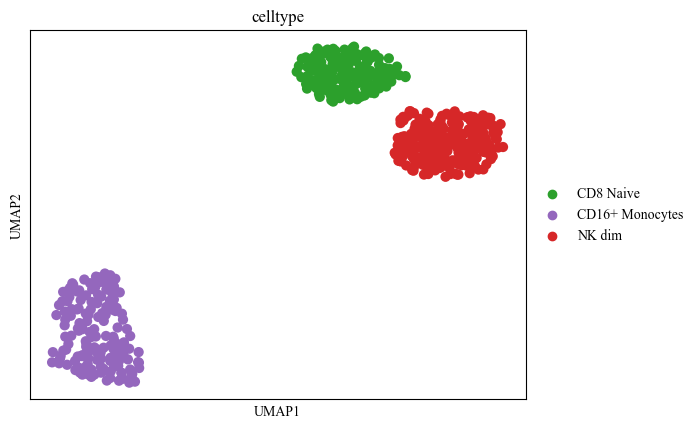

In [4]:
adata_rna.layers["counts"] = adata_rna.X.copy()
sc.pp.normalize_total(adata_rna)
sc.pp.log1p(adata_rna)
sc.pp.highly_variable_genes(adata_rna, n_top_genes=3000)
sc.tl.pca(adata_rna, random_state=666)
sc.pp.neighbors(adata_rna, use_rep='X_pca')
sc.tl.umap(adata_rna, random_state=1)
sc.pl.umap(adata_rna, color=["celltype"], palette={'CD8 Naive':"#2ca02c",'NK dim':"#d62728" ,'CD16+ Monocytes':"#9467bd",})
#sc.pl.umap(adata_rna, color=["celltype"], palette={'CD8 Naive':"#2ca02c",'NK dim':"#d62728" ,'CD16+ Monocytes':"#9467bd",}, save="_scRNA.pdf")

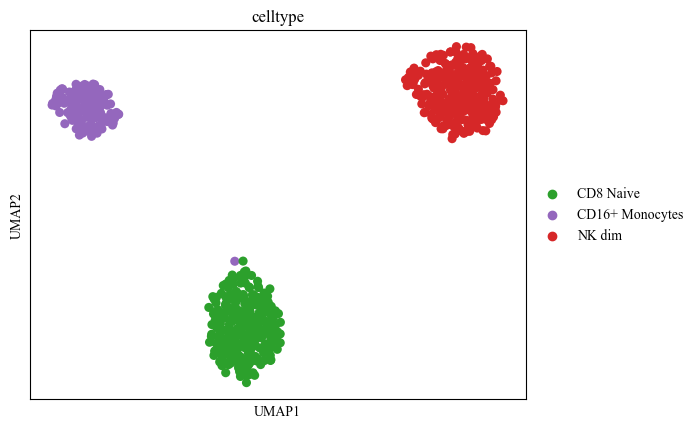

In [5]:
adata_atac.layers["counts"] = adata_atac.X.copy()
sc.pp.normalize_total(adata_atac)
sc.pp.log1p(adata_atac)
sc.pp.highly_variable_genes(adata_atac, n_top_genes=3000)
sc.tl.pca(adata_atac, random_state=666)
sc.pp.neighbors(adata_atac, use_rep='X_pca')
sc.tl.umap(adata_atac, random_state=666)
sc.pl.umap(adata_atac, color=["celltype"], palette={'CD8 Naive':"#2ca02c",'NK dim':"#d62728" ,'CD16+ Monocytes':"#9467bd",})
#sc.pl.umap(adata_atac, color=["celltype"], palette={'CD8 Naive':"#2ca02c",'NK dim':"#d62728" ,'CD16+ Monocytes':"#9467bd",}, save="_scATAC.pdf")

In [6]:
K1 = np.load("../../Data/PBMC_3CT/K1.npy")
K2 = np.load("../../Data/PBMC_3CT/K2.npy")
alpha = pd.read_csv('/home/bateer/Projects/09_Bateer_MMDMAT_2025/07_Manuscript/02_temp_manuscript/Data/PBMC_3CT/MMDMAT_result/results_nfeat_5_sigma_0.5_lam1_1e-09_lam2_1e-07_lam3_0.5//seed_5/alpha_hat_5_3000.txt', sep=r'\s+', header=None)
beta = pd.read_csv('/home/bateer/Projects/09_Bateer_MMDMAT_2025/07_Manuscript/02_temp_manuscript/Data/PBMC_3CT/MMDMAT_result/results_nfeat_5_sigma_0.5_lam1_1e-09_lam2_1e-07_lam3_0.5/seed_5/beta_hat_5_3000.txt', sep=r'\s+', header=None)
Z1 = np.dot(K1, alpha.values)
Z2 = np.dot(K2, beta.values)
MMDMAT_emb = np.vstack((Z1, Z2))
adata.obsm['GLAlign'] = MMDMAT_emb

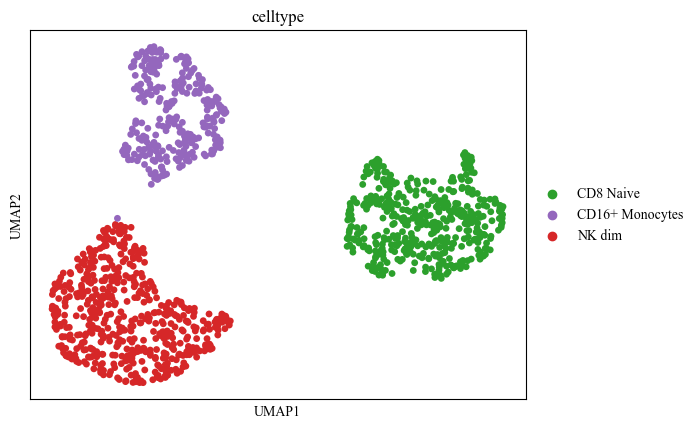

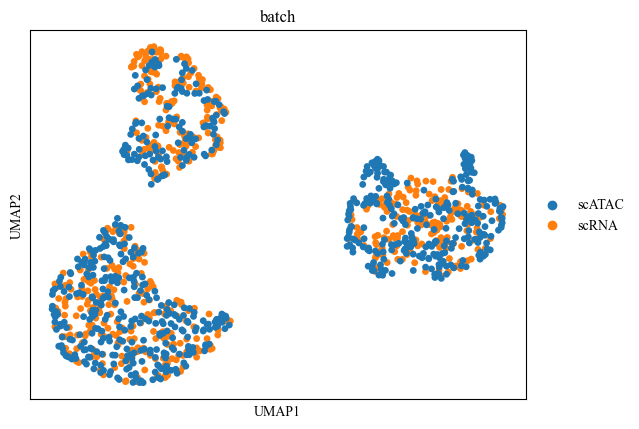

In [7]:
sc.pp.neighbors(adata, use_rep='GLAlign')
sc.tl.umap(adata, random_state=666)
sc.pl.umap(adata, color=["celltype"], palette={'CD8 Naive':"#2ca02c",'NK dim':"#d62728" ,'CD16+ Monocytes':"#9467bd",}, save="_CT_M3Align.pdf")
sc.pl.umap(adata, color=["batch"], save="_batch_M3Align.pdf")
adata.obsm['GLAlign_umap'] = adata.obsm['X_umap']